# Missing Values Analysis

Explore patterns of missing data across the pm_all dataset, with a focus on `smogI` missingness. Is the high rate of missing `smogI` values specific to Montana, or a broader issue?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
import os
_eda_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else (os.getcwd() if not os.path.exists('eda') else os.path.join(os.getcwd(), 'eda'))

pm_all = pd.read_csv(os.path.join(_eda_dir, '..', 'data', 'pm25_data_complete_2003-2021_nodups_051922.csv'), low_memory=False)
pm_fixed = pd.read_csv(os.path.join(_eda_dir, 'pm25_locs_with_states.csv'))

pm_all['date'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')
pm_all['year'] = pm_all['date'].dt.year

# join state info
pm_all = pm_all.merge(pm_fixed[['ll_id', 'state']], on='ll_id', how='left')

print(f"Shape: {pm_all.shape}")
print(f"Date range: {pm_all['date'].min()} to {pm_all['date'].max()}")
print(f"States: {pm_all['state'].nunique()}")

Shape: (2077111, 23)
Date range: 2003-01-01 00:00:00 to 2022-01-06 00:00:00
States: 15


## Overall missing values by feature

In [3]:
# summary table of missingness for all columns
missing = pm_all.isnull().sum()
missing_pct = (missing / len(pm_all) * 100).round(2)

missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct,
    'n_present': len(pm_all) - missing
}).sort_values('pct_missing', ascending=False)

missing_df[missing_df['n_missing'] > 0]

,n_missing,pct_missing,n_present
smogI,1855274,89.32,221837
aot_raw,681307,32.80,1395804
cadI,221837,10.68,1855274
id,86338,4.16,1990773
state,86159,4.15,1990952


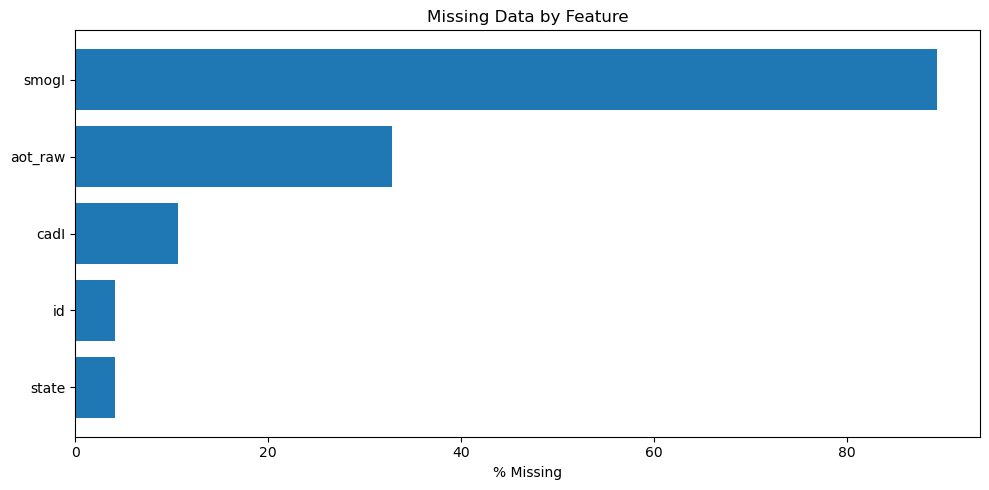

In [4]:
# bar chart of missing % for features with any missingness
cols_with_missing = missing_df[missing_df['n_missing'] > 0].index

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(cols_with_missing)), missing_df.loc[cols_with_missing, 'pct_missing'])
ax.set_yticks(range(len(cols_with_missing)))
ax.set_yticklabels(cols_with_missing)
ax.set_xlabel('% Missing')
ax.set_title('Missing Data by Feature')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## smogI missingness

In [5]:
pm_all['smogI_missing'] = pm_all['smogI'].isnull()

total = len(pm_all)
n_missing = pm_all['smogI_missing'].sum()
print(f"smogI: {n_missing:,} / {total:,} missing ({n_missing/total*100:.1f}%)")

smogI: 1,855,274 / 2,077,111 missing (89.3%)


### smogI missingness by state

In [6]:
state_missing = pm_all.groupby('state').agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
state_missing['pct_missing'] = (state_missing['n_missing'] / state_missing['n_obs'] * 100).round(1)
state_missing = state_missing.sort_values('pct_missing', ascending=False)
state_missing

,n_obs,n_missing,pct_missing
state,,,
NE,1716,1708,99.5
NM,94606,88753,93.8
SD,8248,7708,93.5
MT,118294,109637,92.7
WA,356807,329967,92.5
AZ,104766,95114,90.8
OR,237526,215278,90.6
UT,93501,84626,90.5
CO,84165,75795,90.1


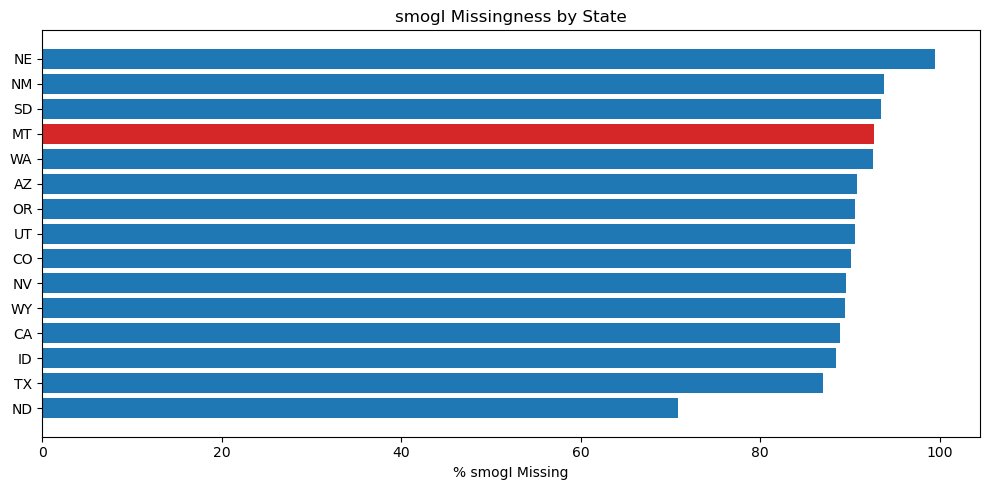

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tab:red' if s == 'MT' else 'tab:blue' for s in state_missing.index]
ax.barh(state_missing.index, state_missing['pct_missing'], color=colors)
ax.set_xlabel('% smogI Missing')
ax.set_title('smogI Missingness by State')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### smogI missingness over time

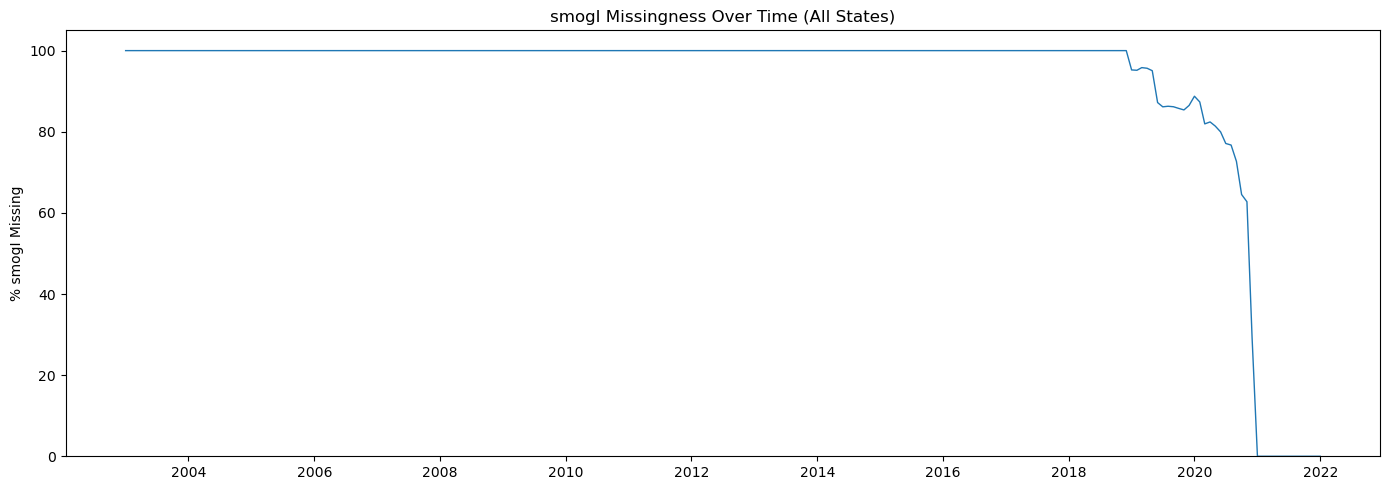

In [8]:
# monthly missingness rate
pm_all['ym'] = pm_all['date'].dt.to_period('M')

monthly_miss = pm_all.groupby('ym').agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
monthly_miss['pct_missing'] = monthly_miss['n_missing'] / monthly_miss['n_obs'] * 100
monthly_miss.index = monthly_miss.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_miss.index, monthly_miss['pct_missing'], linewidth=1)
ax.set_ylabel('% smogI Missing')
ax.set_title('smogI Missingness Over Time (All States)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

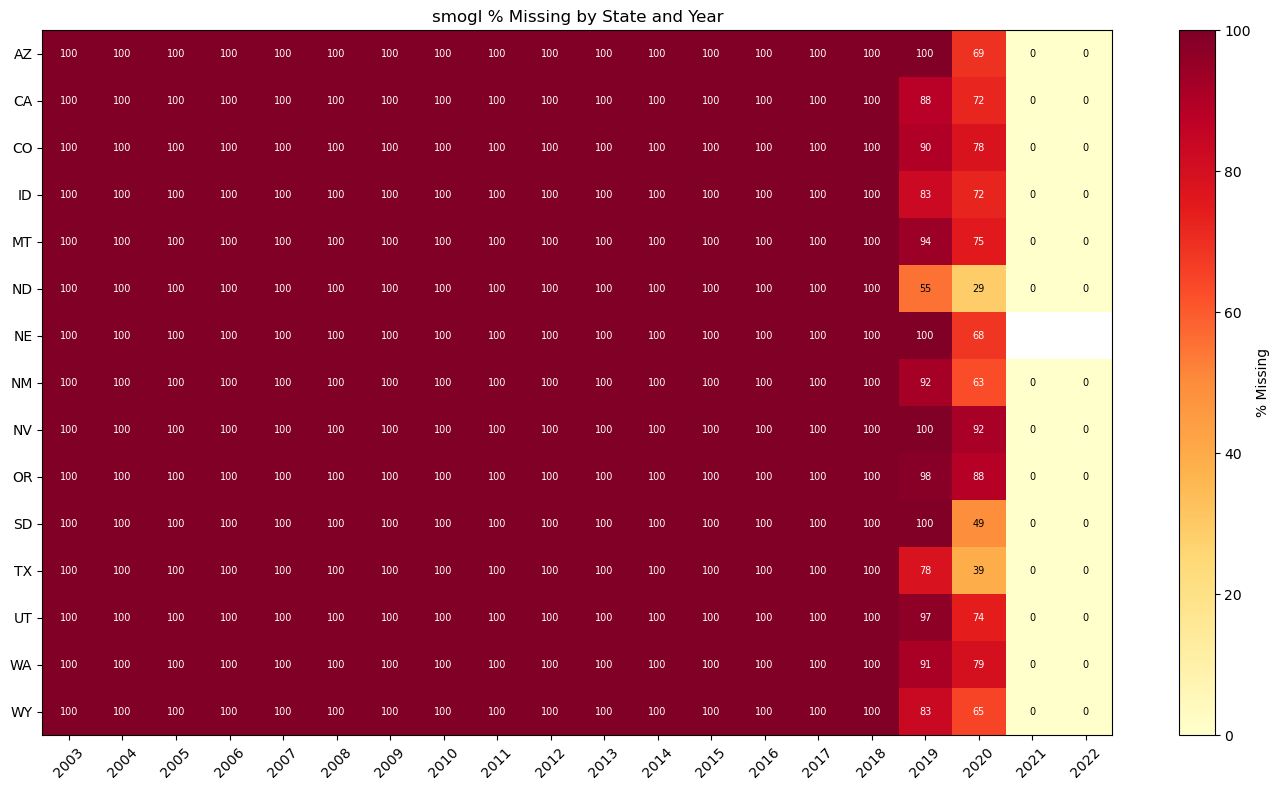

In [9]:
# yearly missingness rate by state
yearly_state_miss = pm_all.groupby(['year', 'state']).agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
yearly_state_miss['pct_missing'] = (yearly_state_miss['n_missing'] / yearly_state_miss['n_obs'] * 100).round(1)
yearly_state_miss = yearly_state_miss.reset_index()

# pivot for heatmap
pivot = yearly_state_miss.pivot(index='state', columns='year', values='pct_missing')

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('smogI % Missing by State and Year')
plt.colorbar(im, ax=ax, label='% Missing')

# annotate cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 60 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.show()

### Montana vs. rest of dataset

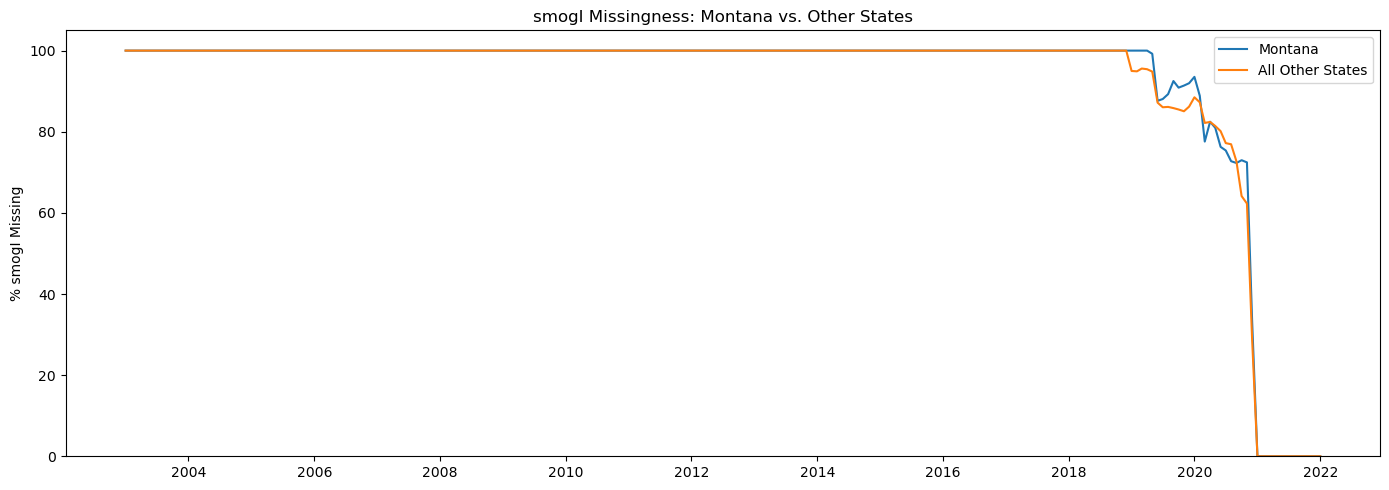

In [10]:
# compare monthly missingness: Montana vs all other states
mt = pm_all[pm_all['state'] == 'MT']
non_mt = pm_all[pm_all['state'] != 'MT']

mt_monthly = mt.groupby('ym').agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
mt_monthly['pct_missing'] = mt_monthly['n_missing'] / mt_monthly['n_obs'] * 100
mt_monthly.index = mt_monthly.index.to_timestamp()

non_mt_monthly = non_mt.groupby('ym').agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
non_mt_monthly['pct_missing'] = non_mt_monthly['n_missing'] / non_mt_monthly['n_obs'] * 100
non_mt_monthly.index = non_mt_monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mt_monthly.index, mt_monthly['pct_missing'], label='Montana', linewidth=1.5)
ax.plot(non_mt_monthly.index, non_mt_monthly['pct_missing'], label='All Other States', linewidth=1.5)
ax.set_ylabel('% smogI Missing')
ax.set_title('smogI Missingness: Montana vs. Other States')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Is smogI missingness correlated with other features being missing?

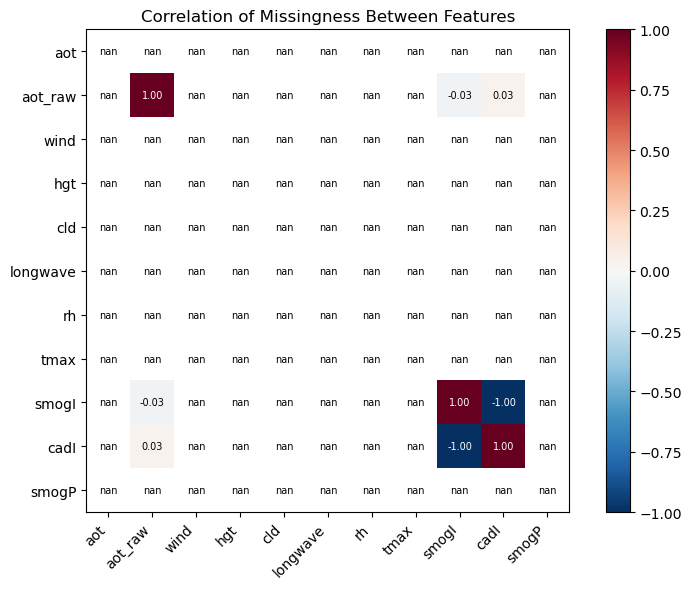

In [11]:
# check if smogI tends to be missing when other time-varying features are also missing
time_varying = ['aot', 'aot_raw', 'wind', 'hgt', 'cld', 'longwave', 'rh', 'tmax', 'smogI', 'cadI', 'smogP']
present_cols = [c for c in time_varying if c in pm_all.columns]

missing_matrix = pm_all[present_cols].isnull()

# correlation of missingness indicators
miss_corr = missing_matrix.astype(int).corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(miss_corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(miss_corr.columns)))
ax.set_xticklabels(miss_corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(miss_corr.index)))
ax.set_yticklabels(miss_corr.index)
ax.set_title('Correlation of Missingness Between Features')
plt.colorbar(im, ax=ax)

for i in range(len(miss_corr.index)):
    for j in range(len(miss_corr.columns)):
        val = miss_corr.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.show()

In [12]:
# when smogI is missing, what fraction of other features are also missing?
smogI_missing_rows = pm_all[pm_all['smogI_missing']]
smogI_present_rows = pm_all[~pm_all['smogI_missing']]

other_features = [c for c in present_cols if c != 'smogI']

comparison = pd.DataFrame({
    'pct_missing_when_smogI_missing': (smogI_missing_rows[other_features].isnull().mean() * 100).round(1),
    'pct_missing_when_smogI_present': (smogI_present_rows[other_features].isnull().mean() * 100).round(1)
})
comparison

,pct_missing_when_smogI_missing,pct_missing_when_smogI_present
aot,0.0,0.0
aot_raw,32.2,37.4
wind,0.0,0.0
hgt,0.0,0.0
cld,0.0,0.0
longwave,0.0,0.0
rh,0.0,0.0
tmax,0.0,0.0
cadI,0.0,100.0
smogP,0.0,0.0


### Seasonal pattern of smogI missingness

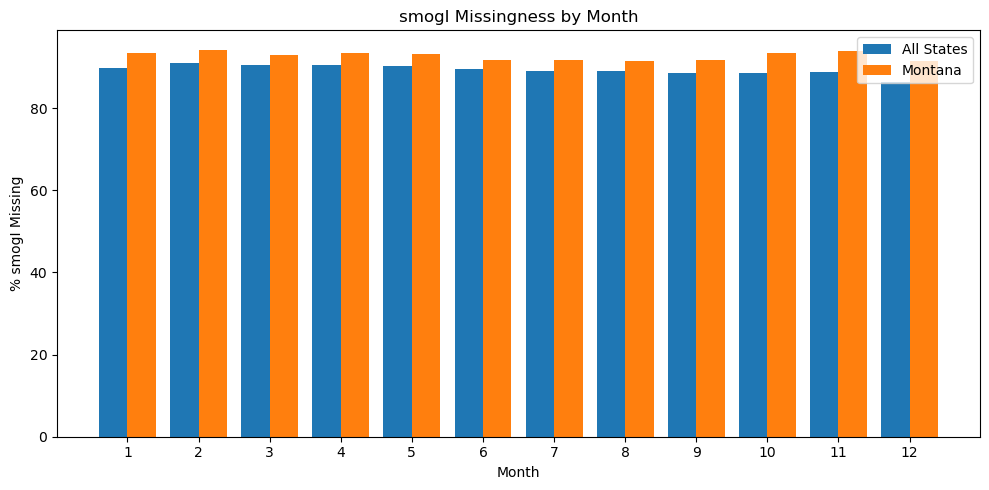

In [13]:
pm_all['month'] = pm_all['date'].dt.month

seasonal = pm_all.groupby('month').agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
seasonal['pct_missing'] = seasonal['n_missing'] / seasonal['n_obs'] * 100

seasonal_mt = mt.groupby(mt['date'].dt.month).agg(
    n_obs=('smogI', 'size'),
    n_missing=('smogI_missing', 'sum')
)
seasonal_mt['pct_missing'] = seasonal_mt['n_missing'] / seasonal_mt['n_obs'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonal.index - 0.2, seasonal['pct_missing'], width=0.4, label='All States')
ax.bar(seasonal_mt.index + 0.2, seasonal_mt['pct_missing'], width=0.4, label='Montana')
ax.set_xlabel('Month')
ax.set_ylabel('% smogI Missing')
ax.set_title('smogI Missingness by Month')
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.show()

### cadI vs smogI missingness

The data dictionary notes that `smogI` and `cadI` are described as the same variable. Are they actually identical, or do they differ in availability?

In [14]:
both_present = pm_all.dropna(subset=['smogI', 'cadI'])
print(f"Both present: {len(both_present):,} rows")
print(f"smogI missing, cadI present: {(pm_all['smogI'].isnull() & pm_all['cadI'].notna()).sum():,}")
print(f"smogI present, cadI missing: {(pm_all['smogI'].notna() & pm_all['cadI'].isnull()).sum():,}")
print(f"Both missing: {(pm_all['smogI'].isnull() & pm_all['cadI'].isnull()).sum():,}")

if len(both_present) > 0:
    corr = both_present['smogI'].corr(both_present['cadI'])
    identical = (both_present['smogI'] == both_present['cadI']).all()
    print(f"\nCorrelation when both present: {corr:.4f}")
    print(f"Values identical: {identical}")

Both present: 0 rows
smogI missing, cadI present: 1,855,274
smogI present, cadI missing: 221,837
Both missing: 0


### Summary

In [15]:
print("=== Missing Values Summary ===")
print(f"\nDataset: {len(pm_all):,} rows, {pm_all['state'].nunique()} states, "
      f"{pm_all['year'].min()}-{pm_all['year'].max()}")
print(f"\nOverall smogI missingness: {pm_all['smogI_missing'].mean()*100:.1f}%")
print(f"Montana smogI missingness: {mt['smogI_missing'].mean()*100:.1f}%")
print(f"Non-Montana smogI missingness: {non_mt['smogI_missing'].mean()*100:.1f}%")
print(f"\nMost affected states:")
print(state_missing[['pct_missing']].head(5).to_string())

=== Missing Values Summary ===

Dataset: 2,077,111 rows, 15 states, 2003-2022

Overall smogI missingness: 89.3%
Montana smogI missingness: 92.7%
Non-Montana smogI missingness: 89.1%

Most affected states:
       pct_missing
state             
NE            99.5
NM            93.8
SD            93.5
MT            92.7
WA            92.5


## Are cadI and smogI the same variable?

Since `cadI` and `smogI` are never simultaneously present, we can't correlate them directly. Instead, compare their distributions to see if they appear to measure the same thing.

In [16]:
cadI_vals = pm_all['cadI'].dropna()
smogI_vals = pm_all['smogI'].dropna()

print("=== Descriptive Statistics ===")
stats = pd.DataFrame({
    'cadI': cadI_vals.describe(),
    'smogI': smogI_vals.describe()
})
print(stats.to_string())

print(f"\ncadI  n={len(cadI_vals):,}, skew={cadI_vals.skew():.3f}, kurtosis={cadI_vals.kurtosis():.3f}")
print(f"smogI n={len(smogI_vals):,}, skew={smogI_vals.skew():.3f}, kurtosis={smogI_vals.kurtosis():.3f}")

=== Descriptive Statistics ===


               cadI          smogI
count  1.855274e+06  221837.000000
mean   9.751003e-01       0.613289
std    4.127820e-01       0.195656
min   -1.045607e+00      -0.279421
25%    7.024057e-01       0.482991
50%    1.037113e+00       0.616465
75%    1.288150e+00       0.752765
max    2.042632e+00       1.342428

cadI  n=1,855,274, skew=-0.549, kurtosis=-0.192
smogI n=221,837, skew=-0.152, kurtosis=-0.143


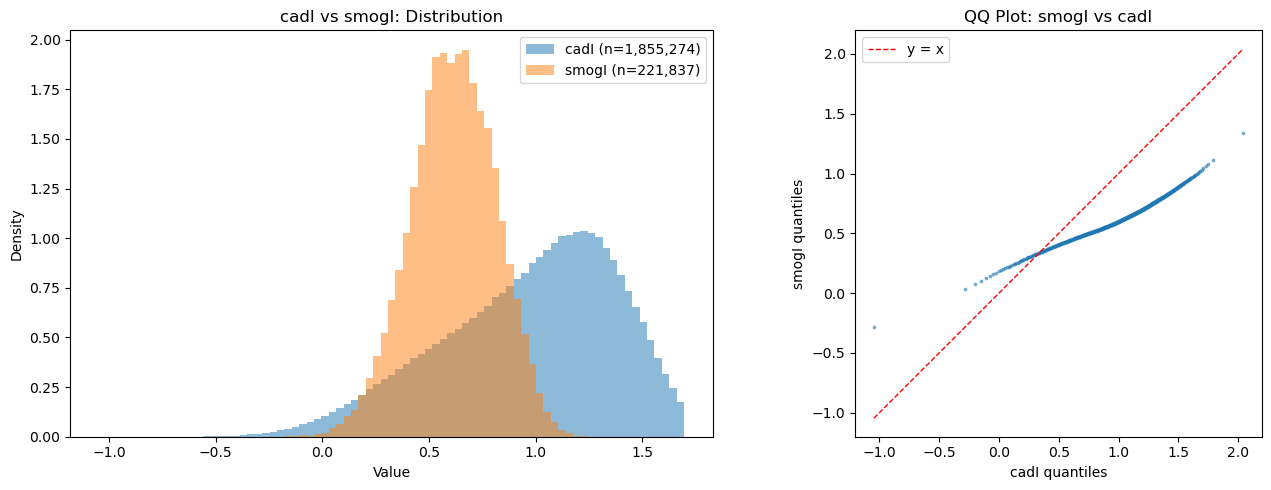

In [17]:
# overlaid histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
bins = np.linspace(
    min(cadI_vals.min(), smogI_vals.min()),
    max(cadI_vals.quantile(0.99), smogI_vals.quantile(0.99)),
    80
)
axes[0].hist(cadI_vals, bins=bins, alpha=0.5, label=f'cadI (n={len(cadI_vals):,})', density=True)
axes[0].hist(smogI_vals, bins=bins, alpha=0.5, label=f'smogI (n={len(smogI_vals):,})', density=True)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('cadI vs smogI: Distribution')
axes[0].legend()

# QQ plot: smogI quantiles vs cadI quantiles
quantiles = np.linspace(0, 1, 500)
cadI_q = np.quantile(cadI_vals, quantiles)
smogI_q = np.quantile(smogI_vals, quantiles)
axes[1].scatter(cadI_q, smogI_q, s=3, alpha=0.5)
q_min = min(cadI_q.min(), smogI_q.min())
q_max = max(cadI_q.max(), smogI_q.max())
axes[1].plot([q_min, q_max], [q_min, q_max], 'r--', linewidth=1, label='y = x')
axes[1].set_xlabel('cadI quantiles')
axes[1].set_ylabel('smogI quantiles')
axes[1].set_title('QQ Plot: smogI vs cadI')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [18]:
# KS test for distributional equivalence
from scipy import stats

ks_stat, ks_pval = stats.ks_2samp(cadI_vals, smogI_vals)
print(f"Two-sample KS test: statistic={ks_stat:.4f}, p-value={ks_pval:.2e}")
if ks_pval < 0.05:
    print("Distributions are statistically different (p < 0.05)")
else:
    print("Cannot reject that distributions are the same (p >= 0.05)")

Two-sample KS test: statistic=0.5465, p-value=0.00e+00
Distributions are statistically different (p < 0.05)


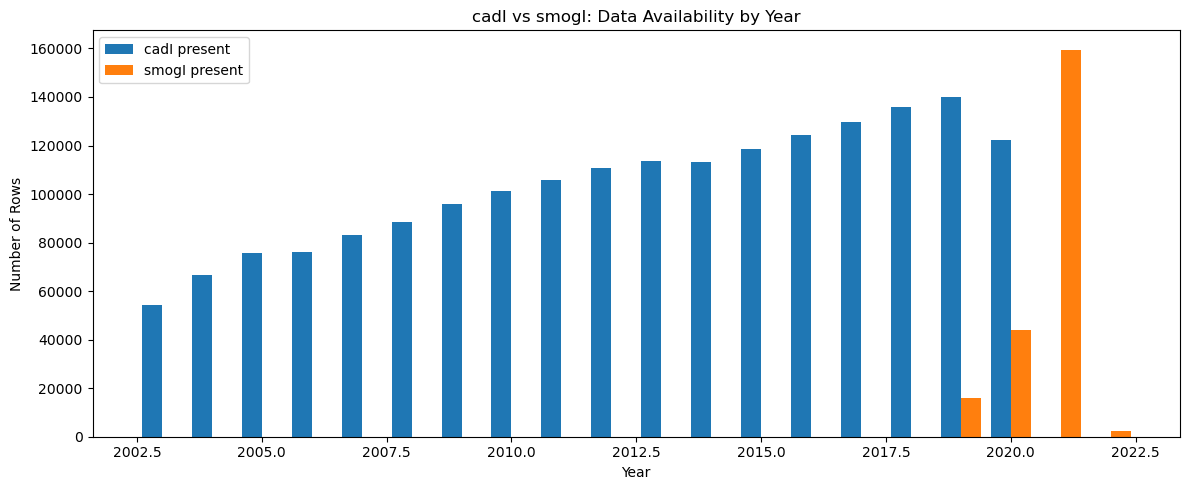

In [19]:
# break down by time period: do cadI and smogI cover different eras?
cadI_years = pm_all.loc[pm_all['cadI'].notna(), 'year'].value_counts().sort_index()
smogI_years = pm_all.loc[pm_all['smogI'].notna(), 'year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(cadI_years.index - 0.2, cadI_years.values, width=0.4, label='cadI present')
ax.bar(smogI_years.index + 0.2, smogI_years.values, width=0.4, label='smogI present')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Rows')
ax.set_title('cadI vs smogI: Data Availability by Year')
ax.legend()
plt.tight_layout()
plt.show()

### Sites with both cadI and smogI observations

No individual row has both variables, but some *sites* may have cadI on some days and smogI on others. For those shared sites, compare per-site distributions to see if the variables track each other.

In [20]:
# which sites have at least some cadI AND some smogI data?
sites_with_cadI = set(pm_all.loc[pm_all['cadI'].notna(), 'll_id'].unique())
sites_with_smogI = set(pm_all.loc[pm_all['smogI'].notna(), 'll_id'].unique())
shared_sites = sites_with_cadI & sites_with_smogI

print(f"Sites with any cadI:  {len(sites_with_cadI)}")
print(f"Sites with any smogI: {len(sites_with_smogI)}")
print(f"Sites with both:      {len(shared_sites)}")
print(f"cadI-only sites:      {len(sites_with_cadI - sites_with_smogI)}")
print(f"smogI-only sites:     {len(sites_with_smogI - sites_with_cadI)}")

Sites with any cadI:  809
Sites with any smogI: 870
Sites with both:      509
cadI-only sites:      300
smogI-only sites:     361


In [21]:
# for shared sites, compute per-site mean/std of each variable
shared_df = pm_all[pm_all['ll_id'].isin(shared_sites)]

site_cadI = (shared_df[shared_df['cadI'].notna()]
             .groupby('ll_id')['cadI']
             .agg(['mean', 'std', 'count'])
             .rename(columns={'mean': 'cadI_mean', 'std': 'cadI_std', 'count': 'cadI_n'}))

site_smogI = (shared_df[shared_df['smogI'].notna()]
              .groupby('ll_id')['smogI']
              .agg(['mean', 'std', 'count'])
              .rename(columns={'mean': 'smogI_mean', 'std': 'smogI_std', 'count': 'smogI_n'}))

site_both = site_cadI.join(site_smogI, how='inner')
print(f"{len(site_both)} sites with both variables")
site_both.head(10)

509 sites with both variables


,cadI_mean,cadI_std,cadI_n,smogI_mean,smogI_std,smogI_n
ll_id,,,,,,
103123_32727,1.040988,0.326784,5197,0.420634,0.214910,386
103274_44087,0.895653,0.379361,4758,0.624564,0.213459,547
103300_47581,0.753044,0.438219,3901,0.617579,0.227993,382
103379_46894,0.780050,0.433908,3559,0.603535,0.222596,378
103484_43558,0.926060,0.351178,4884,0.599543,0.225602,540
103640_48153,0.762919,0.418095,2514,0.716848,0.160723,3
103657_41877,0.953404,0.355419,1042,0.710589,0.149900,8
103658_41876,1.046803,0.299619,205,0.592097,0.209266,421
104405_33460,1.142634,0.308292,1963,0.370674,0.220163,99


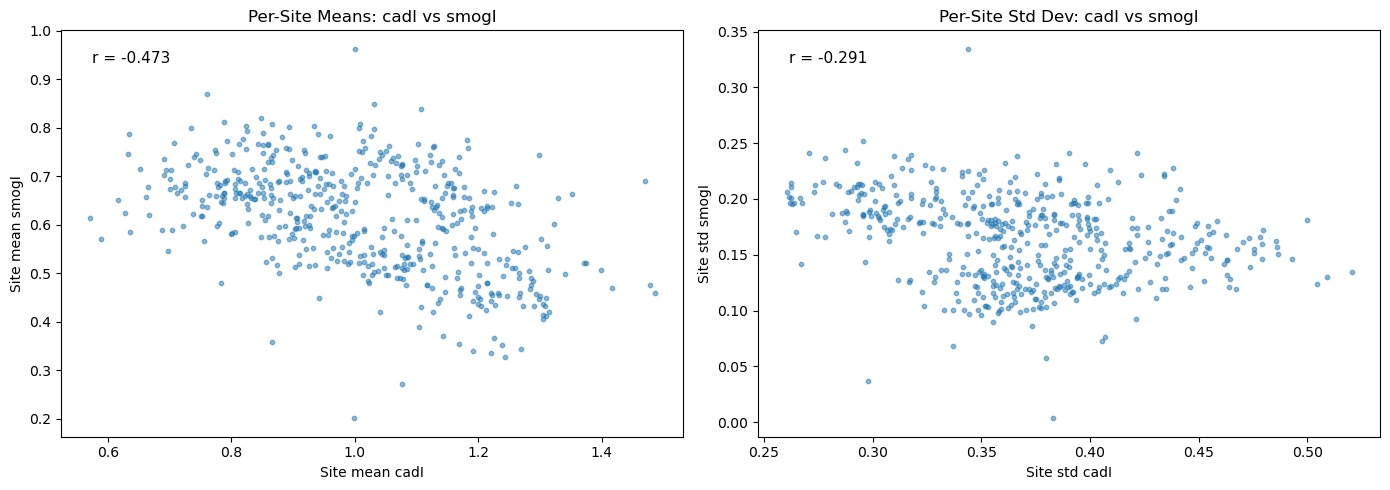

In [22]:
# scatter: per-site cadI mean vs smogI mean
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(site_both['cadI_mean'], site_both['smogI_mean'], s=10, alpha=0.5)
axes[0].set_xlabel('Site mean cadI')
axes[0].set_ylabel('Site mean smogI')
axes[0].set_title('Per-Site Means: cadI vs smogI')
r = site_both['cadI_mean'].corr(site_both['smogI_mean'])
axes[0].annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=11, va='top')

axes[1].scatter(site_both['cadI_std'], site_both['smogI_std'], s=10, alpha=0.5)
axes[1].set_xlabel('Site std cadI')
axes[1].set_ylabel('Site std smogI')
axes[1].set_title('Per-Site Std Dev: cadI vs smogI')
r_std = site_both['cadI_std'].corr(site_both['smogI_std'])
axes[1].annotate(f'r = {r_std:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=11, va='top')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1838391/1291134621.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


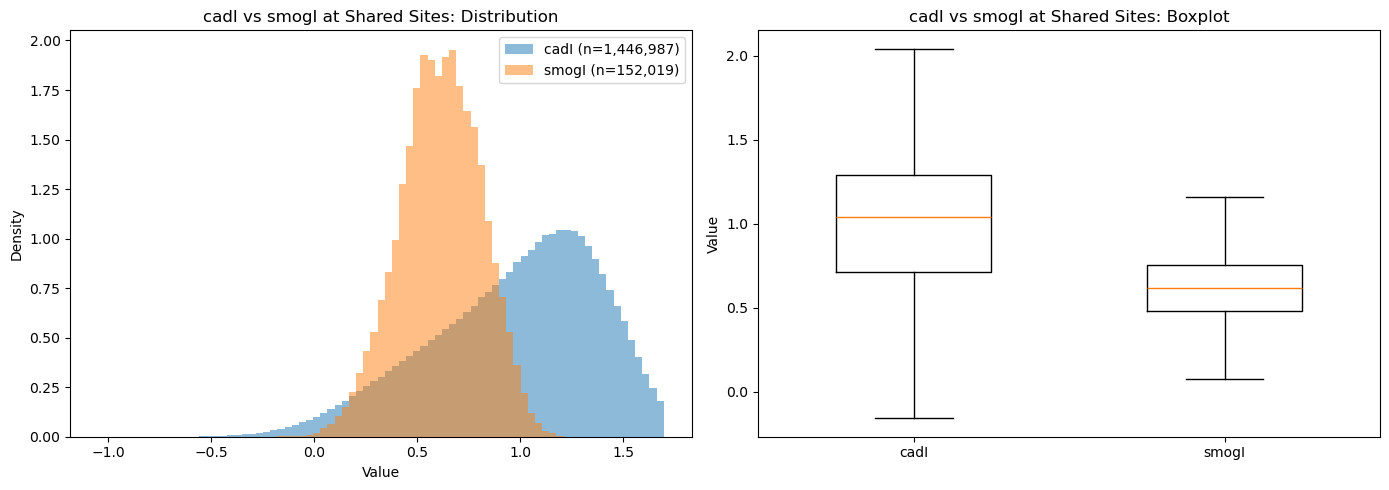

Shared sites - cadI  mean=0.980, std=0.411
Shared sites - smogI mean=0.613, std=0.196


In [23]:
# overlaid distributions restricted to shared sites only
shared_cadI = shared_df.loc[shared_df['cadI'].notna(), 'cadI']
shared_smogI = shared_df.loc[shared_df['smogI'].notna(), 'smogI']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
bins = np.linspace(
    min(shared_cadI.min(), shared_smogI.min()),
    max(shared_cadI.quantile(0.99), shared_smogI.quantile(0.99)),
    80
)
axes[0].hist(shared_cadI, bins=bins, alpha=0.5, density=True, label=f'cadI (n={len(shared_cadI):,})')
axes[0].hist(shared_smogI, bins=bins, alpha=0.5, density=True, label=f'smogI (n={len(shared_smogI):,})')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('cadI vs smogI at Shared Sites: Distribution')
axes[0].legend()

# boxplot side by side
axes[1].boxplot(
    [shared_cadI, shared_smogI],
    labels=['cadI', 'smogI'],
    widths=0.5,
    showfliers=False
)
axes[1].set_ylabel('Value')
axes[1].set_title('cadI vs smogI at Shared Sites: Boxplot')

plt.tight_layout()
plt.show()

print(f"Shared sites - cadI  mean={shared_cadI.mean():.3f}, std={shared_cadI.std():.3f}")
print(f"Shared sites - smogI mean={shared_smogI.mean():.3f}, std={shared_smogI.std():.3f}")

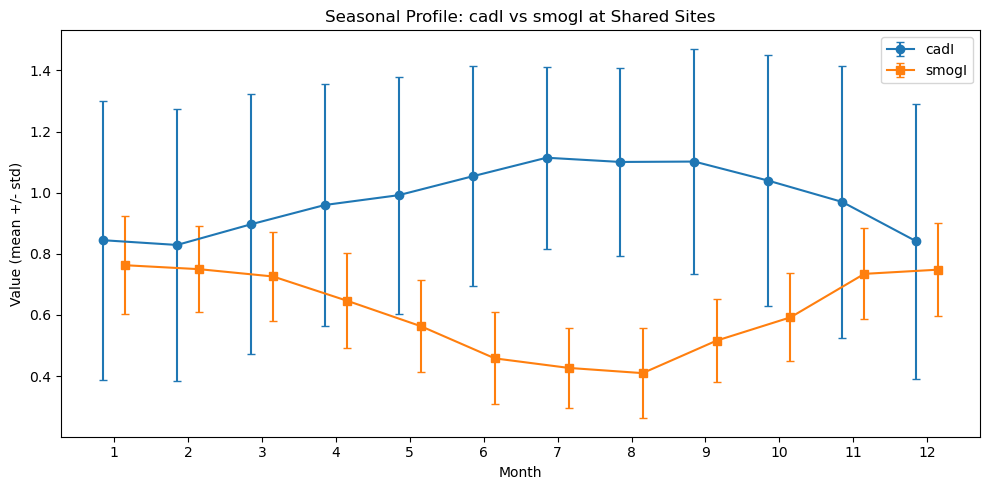

In [24]:
# same-month comparison: for shared sites, compare cadI and smogI
# distributions within the same calendar month (different years)
shared_df_with_month = shared_df.copy()
shared_df_with_month['month'] = shared_df_with_month['date'].dt.month

monthly_cadI = (shared_df_with_month[shared_df_with_month['cadI'].notna()]
                .groupby('month')['cadI'].agg(['mean', 'std']))
monthly_smogI = (shared_df_with_month[shared_df_with_month['smogI'].notna()]
                 .groupby('month')['smogI'].agg(['mean', 'std']))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(monthly_cadI.index - 0.15, monthly_cadI['mean'], yerr=monthly_cadI['std'],
            fmt='o-', capsize=3, label='cadI')
ax.errorbar(monthly_smogI.index + 0.15, monthly_smogI['mean'], yerr=monthly_smogI['std'],
            fmt='s-', capsize=3, label='smogI')
ax.set_xlabel('Month')
ax.set_ylabel('Value (mean +/- std)')
ax.set_title('Seasonal Profile: cadI vs smogI at Shared Sites')
ax.set_xticks(range(1, 13))
ax.legend()
plt.tight_layout()
plt.show()